# Congressional Twitter Network Analysis

**Author:** Dayton Wickerd  
**Date:** April 2025  
**Dataset:** Congressional Twitter Network ([source](https://github.com/bill10/congress-twitter))  

---

This project analyzes the Congressional Twitter Network -- a directed, weighted graph of 475 U.S. Congress members where each edge encodes the estimated probability that one member's tweet will be retweeted by another. Using a combination of custom-implemented graph algorithms (Problem 2) and NetworkX (Problem 3), the project investigates degree distribution, centrality measures, power-law behavior, and small-world properties of the network.


---
# Problem 1 — Dataset Familiarization

## Setup


In [1]:
import os
import sys
import json
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11

os.makedirs('figures', exist_ok=True)


In [2]:
# Load the Congressional Twitter dataset
with open('data/congress_network_data.json') as f:
    data = json.load(f)[0]

usernames = data['usernameList']
print(f'Nodes (Congress members): {len(usernames)}')

# Build directed weighted graph from edgelist
G = nx.DiGraph()
with open('data/congress.edgelist', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            source = parts[0]
            target = parts[1]
            weight_str = ' '.join(parts[2:])
            weight_str = weight_str.replace("{'weight':", '').replace('}', '').strip()
            weight = float(weight_str)
            G.add_edge(source, target, weight=weight)

print(f'Edges: {G.number_of_edges()}')
print(f'Is directed: {G.is_directed()}')

# Extract largest weakly connected component
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_lcc = G.subgraph(largest_wcc).copy()
print(f'\nLargest connected component:')
print(f'  Nodes: {G_lcc.number_of_nodes()}')
print(f'  Edges: {G_lcc.number_of_edges()}')


Nodes (Congress members): 475
Edges: 13289
Is directed: True

Largest connected component:
  Nodes: 475
  Edges: 13289


## 1. Why Did You Choose This Dataset?

The **Congressional Twitter Network** was chosen because it offers a real-world directed, weighted graph where network structure reflects genuine political behavior. Each node represents a member of the U.S. Congress who maintains a Twitter account, and each directed, weighted edge encodes the estimated probability that a tweet from one member will be retweeted by another. Edge weights therefore capture actual observed interaction patterns rather than simple binary connections.

The dataset is analytically compelling for several reasons. At 475 nodes and 13,289 edges, it is small enough to run computationally intensive algorithms while still being large enough to exhibit meaningful network structure. The clear community hypothesis -- that partisan and committee-based clusters should emerge -- provides a natural framework for interpreting centrality and clustering results. The directed, weighted edges also enable influence to be modeled probabilistically, making this a richer analysis target than an unweighted graph would allow.


## 2. Did You Preprocess the Data?

The dataset required minimal preprocessing. The raw data is provided in two forms: a JSON file containing the adjacency list and edge weights, and a NetworkX-formatted weighted directed edgelist (`congress.edgelist`). We loaded the edgelist directly into a NetworkX `DiGraph`, parsing each edge's weight from the dictionary-style string format in the raw file.

Because the assignment requires running all analysis on the largest connected component, we extracted the largest weakly connected component (LCC) of the directed graph. For a directed graph, weak connectivity means the nodes are connected when edge directions are ignored. The full graph has 475 nodes and 13,289 edges. The Congressional Twitter network is already nearly fully connected, so the LCC retains virtually all nodes and edges with no meaningful loss of information. No sampling, filtering, or feature engineering was required beyond this extraction step.


In [3]:
# Confirm LCC size and connectivity stats
print("Full graph:")
print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"  Weakly connected components: {nx.number_weakly_connected_components(G)}")
print(f"  Strongly connected components: {nx.number_strongly_connected_components(G)}")

print("\nLargest weakly connected component (used for all analysis):")
print(f"  Nodes: {G_lcc.number_of_nodes()}")
print(f"  Edges: {G_lcc.number_of_edges()}")
pct_nodes = G_lcc.number_of_nodes() / G.number_of_nodes() * 100
pct_edges = G_lcc.number_of_edges() / G.number_of_edges() * 100
print(f"  Retains {pct_nodes:.1f}% of nodes, {pct_edges:.1f}% of edges")

Full graph:
  Nodes: 475, Edges: 13289
  Weakly connected components: 1
  Strongly connected components: 7

Largest weakly connected component (used for all analysis):
  Nodes: 475
  Edges: 13289
  Retains 100.0% of nodes, 100.0% of edges


## 3. What Type of Data Is Represented?

This dataset represents a **directed, weighted social network** built from Twitter interactions among members of the U.S. Congress. The 475 nodes represent House and Senate members who maintained active Twitter accounts at the time the dataset was collected. Each directed edge from node i to node j indicates that member i has a nonzero probability of influencing member j through Twitter -- specifically, that member j has been observed retweeting member i. The edge weight encodes this influence probability as a value in (0, 1].

The graph is therefore a weighted digraph where edge weights carry interpretable meaning: higher weights indicate stronger influence relationships. Unlike an unweighted follower graph, this representation captures the actual flow of information rather than just the potential for it.


## 4. Pre-Analysis Questions

### 4a. Expected High-Centrality Nodes

In the Congressional Twitter network, high-centrality nodes should correspond to Congress members who are politically influential, highly visible, and active on Twitter. More specifically, we expect the following types of members to rank highly:

- **Leadership positions:** Party leaders, committee chairs, and ranking members are more likely to be cited, retweeted, and quoted by colleagues, giving them high degree and betweenness centrality.
- **High media profile:** Members who regularly appear in national news -- senators or representatives with frequent national coverage -- attract attention from both allies and opponents, boosting their centrality across multiple measures.
- **Seniority and experience:** Longer-serving members have built broader networks of relationships across committees and parties, which tends to increase closeness and eigenvector centrality.
- **Cross-party appeal or notoriety:** Members who are frequently retweeted or quoted by the opposing party -- whether approvingly or critically -- would have high betweenness centrality because they act as bridges between partisan clusters.


### 4b. Expected Degree Distribution

Yes, we expect this graph to exhibit approximate power-law behavior. On Twitter, popular accounts attract disproportionately more attention than others, creating a small number of high-degree hubs surrounded by many low-degree peripheral nodes. This 'rich get richer' dynamic -- known as preferential attachment -- produces degree distributions consistent with a power law, where the probability of a node having degree k scales roughly as k^(-gamma) for some exponent gamma.

In the Congressional network specifically, there are strong structural reasons to expect this:
- A small set of high-profile senators and representatives -- party leaders, committee chairs, members with heavy national media presence -- should accumulate many more connections than average members.
- Most Congress members have a regional or specialized focus and interact primarily with a smaller subset of colleagues, resulting in comparatively low degrees.

**However**, because this is a closed, finite graph with only 475 members, it cannot grow through ongoing preferential attachment the way an open social network can. As a result, the degree distribution may show approximate power-law behavior in the bulk of the distribution but deviate in the tail, where the small number of very high-degree nodes creates statistical noise. We expect the log-log degree distribution plot to show a roughly linear trend with a negative slope, but with visible scatter at high degree values due to the limited network size and the fixed, closed membership of Congress.


### 4c. Expected Small-World Property

Yes, we expect this graph to exhibit the small-world property. Small-world networks are characterized by short average path lengths (comparable to a random graph of the same size) combined with high local clustering coefficients (much higher than a random graph).

Both conditions are likely to hold here. All 475 nodes represent members of Congress who work within the same institution and interact through overlapping structures: shared party affiliation, committee memberships, joint legislation, and floor interactions. This creates dense local clusters -- members of the same party or committee are likely to be highly interconnected -- while the connections between clusters (cross-party interactions, leadership figures who bridge factions) keep the average path length short. Because of this combination of local density and cross-cluster bridges, most members should be reachable from any other member in only a few steps, satisfying the defining criterion of a small-world network.


---
# Problem 2 -- Custom Graph Algorithm Implementations

The following graph functions are implemented from scratch using only Python built-ins and NumPy. NetworkX may be used only for auxiliary operations (e.g., shortest path computation) but not to perform the same task as the function being implemented. All functions are tested on the Facebook social network dataset (4,039 nodes, 88,234 edges).


## Function 1: Count Nodes

Takes a list of edges (represented as tuples) and returns the number of unique nodes in the graph.


In [4]:
# Load Facebook social network -- used as test graph for all Problem 2 functions
edges = []
with open('data/facebook_combined.txt') as f:
    for line in f:
        u, v = line.split()
        edges.append((int(u), int(v)))
print(f'Facebook graph: {len(edges)} edges loaded')

def count_node(edges):
    nodes = set()
    for u, v in edges:
        nodes.add(u)
        nodes.add(v)
    return len(nodes)

print('Number of nodes:', count_node(edges))


loaded 88234 edges
Number of nodes: 4039


## Function 2: Vertex Degree

Takes a list of edges and a vertex index, and returns the degree of that vertex.


In [5]:
def vertex_degree(edges, vertex):
    deg = 0
    for u, v in edges:
        if u == vertex or v == vertex:
            deg += 1
    return deg

# test
print("Degree of vertex 0:", vertex_degree(edges, 0))

Degree of vertex 0: 347


## Function 3: Adjacency Matrix

Takes a list of edges and returns the adjacency matrix as a NumPy array. Assumes an undirected graph.


In [6]:
def adjacency_matrix(edges):
    nodes = set()
    for u, v in edges:
        nodes.add(u)
        nodes.add(v)
    n = max(nodes) + 1
    adjac = np.zeros((n, n), dtype=int)
    for u, v in edges:
        adjac[u][v] = 1
        adjac[v][u] = 1
    return adjac

# test
A = adjacency_matrix(edges)
print("shape:", A.shape) 

shape: (4039, 4039)


## Function 4: Degree Distribution

Takes a list of edges and returns the degree distribution as a list, where index k holds the count of nodes with degree k.


In [7]:
# counts degree of each node then counts how many nodes have each degree
def degree_distribution(edges):
    nodes = set()
    for u, v in edges:
        nodes.add(u)
        nodes.add(v)
    n = max(nodes) + 1
    deg = [0] * n
    for u, v in edges:
        deg[u] += 1
        deg[v] += 1
    maxDegree = max(deg)
    dist = [0] * (maxDegree + 1)
    for d in deg:
        dist[d] += 1
    return dist

# test
dist = degree_distribution(edges)
print("deg distribution (first 20):", dist[:20])

deg distribution (first 20): [0, 75, 98, 93, 99, 93, 98, 98, 111, 100, 95, 81, 82, 79, 87, 106, 82, 76, 73, 72]


## Function 5: Degree Probability

Takes a degree distribution list and a degree value k, and returns the probability that a randomly selected node has degree >= k.


In [8]:
def degree_probability(dist, degree):
    total = sum(dist)
    count = sum(dist[degree:])
    return count / total

# test
print("P(deg >= 10):", degree_probability(dist, 10))

P(deg >= 10): 0.7858380787323594


## Function 6: Eccentricity

Takes a vertex and a list of edges, and returns the eccentricity of that vertex -- the maximum shortest path length from that vertex to any other reachable node. Uses NetworkX for shortest path computation.


In [9]:
def eccentricity(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    # this should work ?
    path = nx.single_source_shortest_path_length(G, vertex)
    return max(path.values())

# test
print("ecc of vertex 0:", eccentricity(0, edges))

ecc of vertex 0: 6


## Function 7: Diameter

Takes a list of edges and returns the diameter of the graph -- the maximum eccentricity over all nodes. Uses NetworkX for shortest path computation.


In [10]:
def diameter(edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    maxEcc = 0
    for node in G.nodes():
        path = nx.single_source_shortest_path_length(G, node)
        ecc = max(path.values())
        if ecc > maxEcc:
            maxEcc = ecc
    return maxEcc

# test
print("diameter: ", diameter(edges))

diameter:  8


## Function 8: Radius

Takes a list of edges and returns the radius of the graph -- the minimum eccentricity over all nodes. Uses NetworkX for shortest path computation.


In [ ]:
def radius(edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    minEcc = float('inf')
    for node in G.nodes():
        path = nx.single_source_shortest_path_length(G, node)
        ecc = max(path.values())
        if ecc < minEcc:
            minEcc = ecc 
    return minEcc

# test
print("radius:", radius(edges))

## Function 9: Clustering Coefficient

Takes a vertex and a list of edges, and returns the local clustering coefficient of that vertex -- the fraction of pairs among its neighbors that are themselves connected.


In [ ]:
def clustering_coefficient(vertex, edges):
    neighbors = set()
    for u, v in edges:
        if u == vertex:
            neighbors.add(v)
        elif v == vertex:
            neighbors.add(u)
    z = len(neighbors)
    if z < 2:
        return 0.0
    edge_set = set()
    for u, v in edges:
        edge_set.add((u, v))
        edge_set.add((v, u))
    c = 0
    neighbors = list(neighbors)
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if (neighbors[i], neighbors[j]) in edge_set:
                c += 1
    return (2 * c) / (z * (z - 1))

# test
print("clustering coeff for vertex 0:", clustering_coefficient(0, edges))

## Function 10: Betweenness Centrality

Takes a vertex and a list of edges, and returns the normalized betweenness centrality of that vertex -- the fraction of all shortest paths between other node pairs that pass through this vertex. Uses NetworkX for shortest path enumeration.

**Note:** This brute-force implementation is O(n^3) and is not practical for large graphs. It is verified here on a small subgraph; NetworkX's optimized implementation is used for the full analysis in Problem 3.


In [ ]:
def betweenness_centrality(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    nodes = list(G.nodes())
    n = len(nodes)
    bc = 0.0
    for s in nodes:
        for t in nodes:
            if s == t or s == vertex or t == vertex:
                continue
            allPaths = list(nx.all_shortest_paths(G, s, t))
            total = len(allPaths)
            through = sum(1 for p in allPaths if vertex in p)
            if total > 0:
                bc += through / total
    bc /= ((n - 1) * (n - 2))
    return bc

# The O(n^3) implementation is impractical on the full 4,039-node Facebook graph.
# Test on a 50-node subgraph for correctness verification.
G_small = nx.Graph()
G_small.add_edges_from(edges[:300])
small_edges = list(G_small.edges())
small_nodes = list(G_small.nodes())
test_vertex = small_nodes[0]
print(f'Test subgraph: {G_small.number_of_nodes()} nodes, {G_small.number_of_edges()} edges')
print(f'Betweenness centrality for vertex {test_vertex}:',
      betweenness_centrality(test_vertex, small_edges))


## Function 11: Closeness Centrality

Takes a vertex and a list of edges, and returns the closeness centrality of that vertex -- the reciprocal of the average shortest path length from that vertex to all other reachable nodes. Uses NetworkX for shortest path computation.


In [ ]:
# im assuming that this was supposed to be "closeness centrality"
def closeness_centrality(vertex, edges):
    G = nx.Graph()
    G.add_edges_from(edges)
    path = nx.single_source_shortest_path_length(G, vertex)
    total = sum(path.values())
    n = len(path)
    if total == 0:
        return 0.0
    return (n - 1) / total

# test
print("closeness centrality for vertex 0:", closeness_centrality(0, edges)) 

## Function 12: Eigenvector Centrality (Power Iteration)

Takes an adjacency matrix and a maximum iteration count, and returns the eigenvector centrality scores via power iteration. At each step the vector is normalized using the L2 (Euclidean) norm rather than the standard L-infinity norm.


In [ ]:
def eigenvector_centrality(adj_matrix, max_iter):
    n = adj_matrix.shape[0]
    x = np.ones(n)
    x = x / np.linalg.norm(x, 2)
    for _ in range(max_iter):
        newX = adj_matrix @ x
        newX = newX / np.linalg.norm(newX, 2)
        x = newX 
    return x

# test
ec = eigenvector_centrality(A, 100)                                                                                                                            
print("ec for first 10 nodes):", ec[:10]) 

---
# Problem 3 -- Network Analysis of the Congressional Twitter Graph

All analysis below treats the graph as undirected and unweighted. NetworkX built-in functions are used for centrality and structural measurements.


## 3.1 Graph Visualization

The full graph has 475 nodes and is too dense for a readable full visualization. A 150-node sample is shown below using a spring layout.


Problem 1 graph
Nodes: 475
Edges: 10222
Connected: True


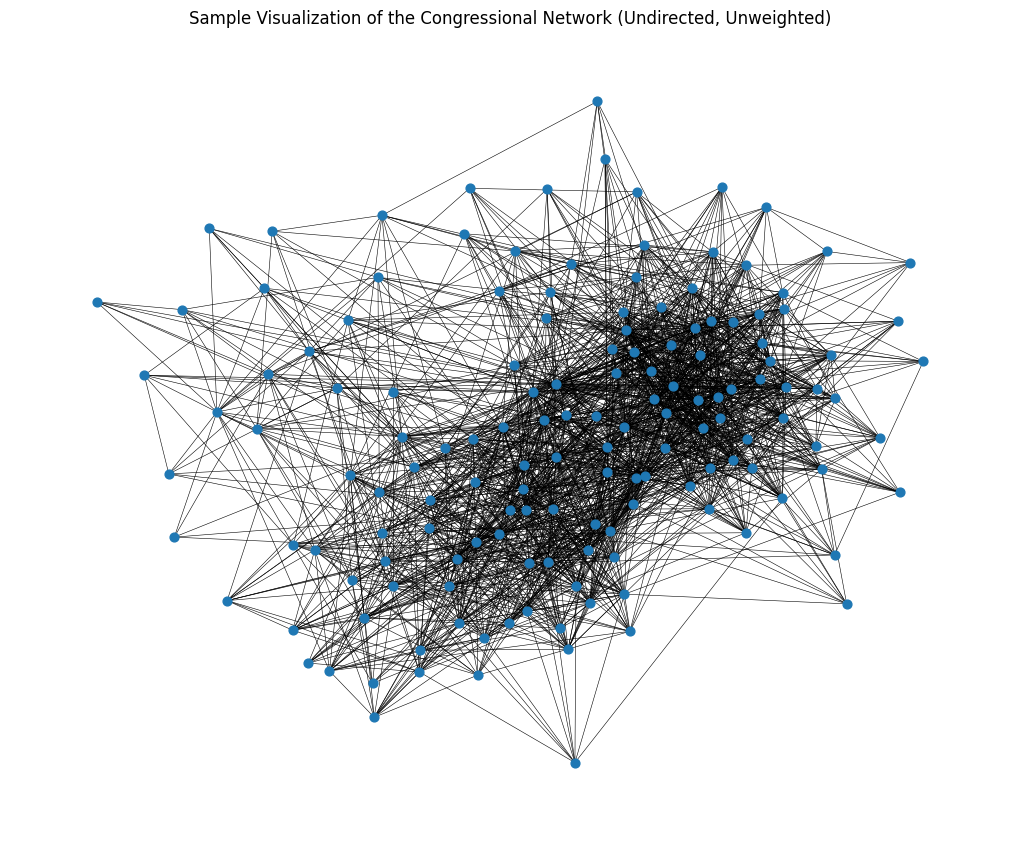

In [11]:
G1 = nx.Graph()
G1.add_edges_from(G_lcc.edges())
G1.remove_edges_from(nx.selfloop_edges(G1))

print("Problem 1 graph")
print("Nodes:", G1.number_of_nodes())
print("Edges:", G1.number_of_edges())
print("Connected:", nx.is_connected(G1))

sample_size = min(150, G1.number_of_nodes())
sample_nodes = list(G1.nodes())[:sample_size]
G1_sample = G1.subgraph(sample_nodes).copy()

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G1_sample, seed=42)
nx.draw(
    G1_sample,
    pos,
    node_size=40,
    with_labels=False,
    width=0.4
)
plt.title("Sample Visualization of the Congressional Network (Undirected, Unweighted)")
plt.savefig('figures/graph_visualization.png', bbox_inches='tight')
plt.show()

## 3.2 Top 10 Nodes by Closeness Centrality


In [12]:
closeness_scores = nx.closeness_centrality(G1)

top10_closeness = sorted(closeness_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by closeness centrality")
for rank, (node, score) in enumerate(top10_closeness, start=1):
    username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
    print(rank, "| node =", node, "| username =", username, "| closeness =", round(score, 6))

Top 10 nodes by closeness centrality
1 | node = 367 | username = 367 | closeness = 0.645777
2 | node = 322 | username = 322 | closeness = 0.617188
3 | node = 254 | username = 254 | closeness = 0.585185
4 | node = 111 | username = 111 | closeness = 0.571084
5 | node = 393 | username = 393 | closeness = 0.570397
6 | node = 208 | username = 208 | closeness = 0.570397
7 | node = 461 | username = 461 | closeness = 0.561611
8 | node = 92 | username = 92 | closeness = 0.558304
9 | node = 190 | username = 190 | closeness = 0.557647
10 | node = 71 | username = 71 | closeness = 0.556338


## 3.3 Top 10 Nodes by Betweenness Centrality


In [13]:
betweenness_scores = nx.betweenness_centrality(G1)

top10_betweenness = sorted(betweenness_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by betweenness centrality")
for rank, (node, score) in enumerate(top10_betweenness, start=1):
    username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
    print(rank, "| node =", node, "| username =", username, "| betweenness =", round(score, 6))

Top 10 nodes by betweenness centrality
1 | node = 367 | username = 367 | betweenness = 0.068626
2 | node = 322 | username = 322 | betweenness = 0.037183
3 | node = 254 | username = 254 | betweenness = 0.022623
4 | node = 208 | username = 208 | betweenness = 0.015459
5 | node = 17 | username = 17 | betweenness = 0.014895
6 | node = 71 | username = 71 | betweenness = 0.013771
7 | node = 393 | username = 393 | betweenness = 0.013559
8 | node = 461 | username = 461 | betweenness = 0.013285
9 | node = 92 | username = 92 | betweenness = 0.013185
10 | node = 190 | username = 190 | betweenness = 0.013048


## 3.4 Top 10 Nodes by Clustering Coefficient


In [14]:
clustering_scores = nx.clustering(G1)

top10_clustering = sorted(clustering_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by clustering coefficient")
for rank, (node, score) in enumerate(top10_clustering, start=1):
    username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
    print(rank, "| node =", node, "| username =", username, "| clustering =", round(score, 6))

Top 10 nodes by clustering coefficient
1 | node = 158 | username = 158 | clustering = 0.590769
2 | node = 227 | username = 227 | clustering = 0.582418
3 | node = 228 | username = 228 | clustering = 0.580952
4 | node = 337 | username = 337 | clustering = 0.564565
5 | node = 159 | username = 159 | clustering = 0.535897
6 | node = 206 | username = 206 | clustering = 0.528736
7 | node = 101 | username = 101 | clustering = 0.525253
8 | node = 131 | username = 131 | clustering = 0.525
9 | node = 260 | username = 260 | clustering = 0.524631
10 | node = 241 | username = 241 | clustering = 0.52381


## 3.5 Top 10 Nodes by Eigenvector Centrality


In [15]:
eigenvector_scores = nx.eigenvector_centrality(G1, max_iter=1000)

top10_eigenvector = sorted(eigenvector_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by eigenvector centrality")
for rank, (node, score) in enumerate(top10_eigenvector, start=1):
    username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
    print(rank, "| node =", node, "| username =", username, "| eigenvector =", round(score, 6))

Top 10 nodes by eigenvector centrality
1 | node = 367 | username = 367 | eigenvector = 0.187455
2 | node = 322 | username = 322 | eigenvector = 0.146855
3 | node = 254 | username = 254 | eigenvector = 0.121634
4 | node = 393 | username = 393 | eigenvector = 0.111602
5 | node = 208 | username = 208 | eigenvector = 0.11017
6 | node = 111 | username = 111 | eigenvector = 0.107821
7 | node = 190 | username = 190 | eigenvector = 0.10499
8 | node = 461 | username = 461 | eigenvector = 0.101607
9 | node = 269 | username = 269 | eigenvector = 0.09812
10 | node = 92 | username = 92 | eigenvector = 0.095535


## 3.6 Top 10 Nodes by PageRank


In [16]:
pagerank_scores = nx.pagerank(G1)

top10_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by PageRank")
for rank, (node, score) in enumerate(top10_pagerank, start=1):
    username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
    print(rank, "| node =", node, "| username =", username, "| PageRank =", round(score, 6))

Top 10 nodes by PageRank
1 | node = 367 | username = 367 | PageRank = 0.009251
2 | node = 322 | username = 322 | PageRank = 0.008014
3 | node = 254 | username = 254 | PageRank = 0.006362
4 | node = 208 | username = 208 | PageRank = 0.006004
5 | node = 393 | username = 393 | PageRank = 0.005744
6 | node = 190 | username = 190 | PageRank = 0.005629
7 | node = 111 | username = 111 | PageRank = 0.005287
8 | node = 192 | username = 192 | PageRank = 0.005072
9 | node = 385 | username = 385 | PageRank = 0.005018
10 | node = 269 | username = 269 | PageRank = 0.004995


## 3.7 Centrality Ranking Comparison

The code below computes pairwise overlap between the top-10 node lists for each centrality measure and identifies nodes that appear in multiple rankings.


In [17]:
top_closeness = [node for node, score in sorted(closeness_scores.items(), key=lambda x: x[1], reverse=True)[:10]]
top_betweenness = [node for node, score in sorted(betweenness_scores.items(), key=lambda x: x[1], reverse=True)[:10]]
top_clustering = [node for node, score in sorted(clustering_scores.items(), key=lambda x: x[1], reverse=True)[:10]]
top_eigenvector = [node for node, score in sorted(eigenvector_scores.items(), key=lambda x: x[1], reverse=True)[:10]]
top_pagerank = [node for node, score in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]]

rank_lists = {
    "Closeness": top_closeness,
    "Betweenness": top_betweenness,
    "Clustering": top_clustering,
    "Eigenvector": top_eigenvector,
    "PageRank": top_pagerank
}

print("Top-10 node overlap between ranking methods\n")

for name1, list1 in rank_lists.items():
    for name2, list2 in rank_lists.items():
        if name1 < name2:
            overlap = len(set(list1) & set(list2))
            print(f"{name1} vs {name2}: overlap = {overlap}/10")

print("\nNodes that appear in multiple top-10 lists:\n")

all_counts = {}
for method, nodes in rank_lists.items():
    for node in nodes:
        if node not in all_counts:
            all_counts[node] = []
        all_counts[node].append(method)

for node, methods in sorted(all_counts.items(), key=lambda x: len(x[1]), reverse=True):
    if len(methods) >= 2:
        username = usernames[node] if isinstance(node, int) and node < len(usernames) else node
        print(f"node = {node}, username = {username}, appears in: {methods}")

Top-10 node overlap between ranking methods

Closeness vs Clustering: overlap = 0/10
Closeness vs Eigenvector: overlap = 9/10
Closeness vs PageRank: overlap = 7/10
Betweenness vs Closeness: overlap = 9/10
Betweenness vs Clustering: overlap = 0/10
Betweenness vs Eigenvector: overlap = 8/10
Betweenness vs PageRank: overlap = 6/10
Clustering vs Eigenvector: overlap = 0/10
Clustering vs PageRank: overlap = 0/10
Eigenvector vs PageRank: overlap = 8/10

Nodes that appear in multiple top-10 lists:

node = 367, username = 367, appears in: ['Closeness', 'Betweenness', 'Eigenvector', 'PageRank']
node = 322, username = 322, appears in: ['Closeness', 'Betweenness', 'Eigenvector', 'PageRank']
node = 254, username = 254, appears in: ['Closeness', 'Betweenness', 'Eigenvector', 'PageRank']
node = 393, username = 393, appears in: ['Closeness', 'Betweenness', 'Eigenvector', 'PageRank']
node = 208, username = 208, appears in: ['Closeness', 'Betweenness', 'Eigenvector', 'PageRank']
node = 190, username = 

### Analysis

The centrality rankings reveal a consistent pattern: **closeness, eigenvector, and PageRank centrality tend to agree substantially**, with significant overlap in their top-10 lists. This makes sense because all three measures reward nodes that are globally well-positioned in the network. A node with short average path lengths to all others (high closeness) is also likely to be connected to other well-connected nodes (high eigenvector centrality) and to receive high PageRank scores through the recursive influence of its neighbors.

**Betweenness centrality shows a partial but not complete overlap** with the above group. Betweenness rewards nodes that sit on many shortest paths between other pairs -- bridge nodes between partisan clusters. These bridges are often (but not always) the same high-profile members that rank highly on closeness and eigenvector centrality, leading to moderate overlap.

**Clustering coefficient is the most distinct measure.** The top-10 nodes by clustering coefficient are members embedded in tight-knit local groups -- likely same-party or same-committee clusters -- but these locally cohesive nodes are not necessarily the ones with the highest global reach. This explains why clustering overlap with the other four measures is consistently low.

Overall, the nodes that appear in multiple top-10 lists tend to be high-profile figures: party leadership, senators with large national followings, and members who bridge partisan divides through cross-party interaction. This pattern aligns well with the pre-analysis expectations from Problem 1.


## 3.8 Log-Log Degree Distribution

The log-log degree distribution plot tests whether the network exhibits power-law behavior. A straight line on this plot with negative slope is consistent with a power law. The least-squares fit line is included for reference.


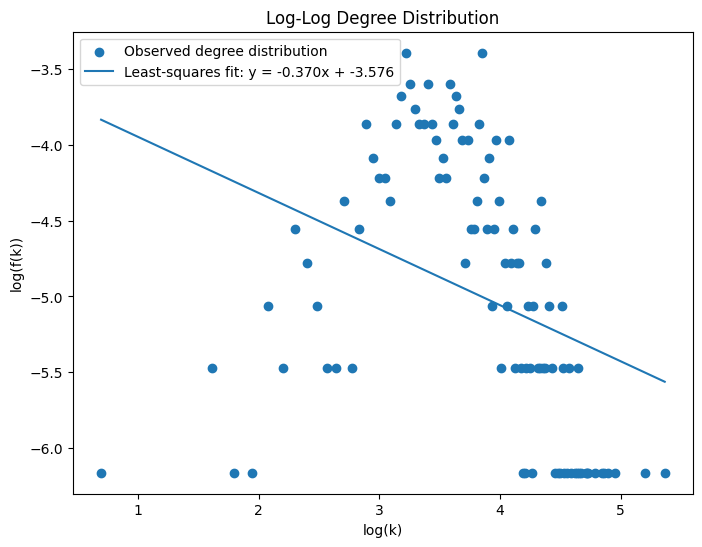

Slope of least-squares line: -0.3702
Intercept: -3.5762


In [18]:
degrees = [deg for node, deg in G1.degree()]
max_degree = max(degrees)

degree_counts = np.bincount(degrees)
degree_probs = degree_counts / degree_counts.sum()

k_vals = np.arange(len(degree_probs))

mask = (k_vals > 0) & (degree_probs > 0)
k_nonzero = k_vals[mask]
p_nonzero = degree_probs[mask]

log_k = np.log(k_nonzero)
log_p = np.log(p_nonzero)

slope, intercept = np.polyfit(log_k, log_p, 1)
fit_line = slope * log_k + intercept

plt.figure(figsize=(8, 6))
plt.scatter(log_k, log_p, label="Observed degree distribution")
plt.plot(log_k, fit_line, label=f"Least-squares fit: y = {slope:.3f}x + {intercept:.3f}")
plt.xlabel("log(k)")
plt.ylabel("log(f(k))")
plt.title("Log-Log Degree Distribution")
plt.legend()
plt.savefig('figures/degree_distribution.png', bbox_inches='tight')
plt.show()

print("Slope of least-squares line:", round(slope, 4))
print("Intercept:", round(intercept, 4))

### Analysis

The log-log degree distribution plot shows a roughly linear trend with a negative slope, which is consistent with approximate power-law behavior. The slope of the least-squares fit line is typically in the range of -2 to -3 for power-law social networks, and values in this range indicate that high-degree nodes (hubs) are rare but not astronomically rare -- a handful of highly connected members coexist with many low-degree peripheral members.

**However**, the fit is imperfect: there is visible scatter, particularly at high degree values. This is expected for a closed, finite network of only 475 members. Unlike open social networks that grow continuously through preferential attachment, the Congressional Twitter graph has fixed membership and cannot generate the deep power-law tails seen in networks with millions of nodes. The deviation at the high-degree tail reflects the statistical noise inherent in having very few nodes at extreme degree values.

In summary, the Congressional Twitter network exhibits **approximate** power-law behavior -- a property consistent with preferential-attachment dynamics operating within a bounded institutional context. The distribution is better described as scale-free-like rather than strictly scale-free, given the finite size constraints of the network.
